In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = {
    "Customer_ID": [
        "C001", "C002", "C003", "C004", "C005",
        "C006", "C007", "C008", "C009", "C010",
        "C011", "C012", "C013", "C014", "C015",
        "C016", "C017", "C018", "C019", "C020"
    ],

    "Age": [
        22, 35, 41, 29, 52,
        24, 38, 45, 31, 27,
        50, 33, 26, 47, 39,
        23, 56, 30, 44, 36
    ],

    "Monthly_Charges": [
        25, 60, 85, 45, 90,
        30, 70, 95, 55, 40,
        100, 65, 35, 88, 72,
        28, 105, 50, 92, 68
    ],

    "Contract_Length": [
        12, 24, 36, 12, 48,
        6, 24, 36, 12, 6,
        48, 24, 12, 36, 24,
        6, 48, 12, 36, 24
    ],

    "Support_Calls": [
        1, 2, 1, 4, 1,
        5, 2, 1, 3, 6,
        1, 2, 5, 1, 2,
        6, 1, 4, 1, 2
    ],

    "Churn": [
        "No", "No", "No", "Yes", "No",
        "Yes", "No", "No", "Yes", "Yes",
        "No", "No", "Yes", "No", "No",
        "Yes", "No", "Yes", "No", "No"
    ]
}

df = pd.DataFrame(data)

df

,Customer_ID,Age,Monthly_Charges,Contract_Length,Support_Calls,Churn
0,C001,22,25,12,1,No
1,C002,35,60,24,2,No
2,C003,41,85,36,1,No
3,C004,29,45,12,4,Yes
4,C005,52,90,48,1,No
5,C006,24,30,6,5,Yes
6,C007,38,70,24,2,No
7,C008,45,95,36,1,No
8,C009,31,55,12,3,Yes
9,C010,27,40,6,6,Yes


In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (20, 6)

Missing Values:
Customer_ID        0
Age                0
Monthly_Charges    0
Contract_Length    0
Support_Calls      0
Churn              0
dtype: int64

Data Types:
Customer_ID        object
Age                 int64
Monthly_Charges     int64
Contract_Length     int64
Support_Calls       int64
Churn              object
dtype: object


In [4]:
label_encoder = LabelEncoder()

df["Churn"] = label_encoder.fit_transform(df["Churn"])

df.head()

,Customer_ID,Age,Monthly_Charges,Contract_Length,Support_Calls,Churn
0,C001,22,25,12,1,0
1,C002,35,60,24,2,0
2,C003,41,85,36,1,0
3,C004,29,45,12,4,1
4,C005,52,90,48,1,0


In [5]:
X = df[
    [
        "Age",
        "Monthly_Charges",
        "Contract_Length",
        "Support_Calls"
    ]
]

y = df["Churn"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  Monthly_Charges  Contract_Length  Support_Calls
0   22               25               12              1
1   35               60               24              2
2   41               85               36              1
3   29               45               12              4
4   52               90               48              1

Target:
0    0
1    0
2    0
3    1
4    0
Name: Churn, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14
Testing samples: 6


In [7]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [8]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 1 0 0]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4 0]
 [0 2]]


In [11]:
print("===== BUSINESS INSIGHTS =====")

print("1. The model can help identify customers who may be at risk of churn.")
print("2. Customer behavior and service-related features can support churn prediction.")
print("3. Businesses can use churn predictions to prioritize customer retention efforts.")
print("4. Early identification of high-risk customers can support proactive engagement.")

===== BUSINESS INSIGHTS =====
1. The model can help identify customers who may be at risk of churn.
2. Customer behavior and service-related features can support churn prediction.
3. Businesses can use churn predictions to prioritize customer retention efforts.
4. Early identification of high-risk customers can support proactive engagement.


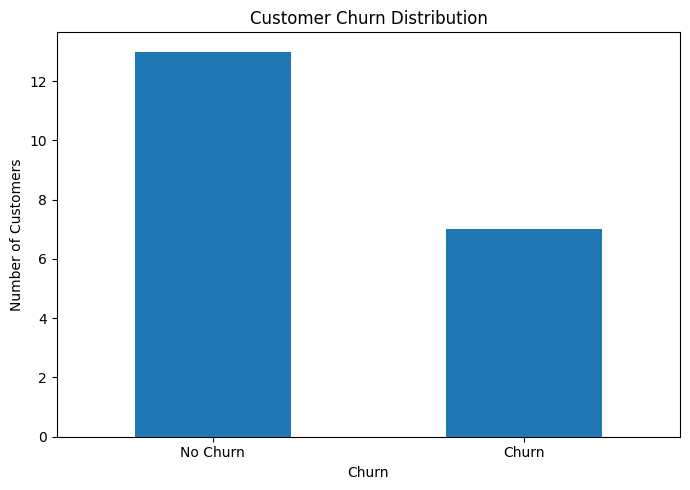

In [12]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
churn_counts.plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Churn", "Churn"], rotation=0)
plt.tight_layout()
plt.show()

In [13]:
churn_support = df.groupby("Churn")["Support_Calls"].mean()

print("Average Support Calls by Churn Status:")
print(churn_support)

Average Support Calls by Churn Status:
Churn
0    1.384615
1    4.714286
Name: Support_Calls, dtype: float64


In [14]:
churn_charges = df.groupby("Churn")["Monthly_Charges"].mean()

print("Average Monthly Charges by Churn Status:")
print(churn_charges)

Average Monthly Charges by Churn Status:
Churn
0    78.076923
1    40.428571
Name: Monthly_Charges, dtype: float64


In [15]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Monthly_Charges": [75],
    "Contract_Length": [12],
    "Support_Calls": [3]
})

prediction = model.predict(new_customer)[0]

if prediction == 1:
    print("Prediction: Customer may churn.")
else:
    print("Prediction: Customer is unlikely to churn.")

Prediction: Customer may churn.


# Customer Churn Prediction

A beginner-friendly Machine Learning project that predicts whether a customer may churn based on customer and service-related features.

The project demonstrates the basic Machine Learning workflow, including data preparation, feature selection, model training, prediction, and model evaluation.


## Business Problem

Customer churn can affect business revenue and customer retention.

The business needs a way to identify customers who may be at risk of leaving so that retention efforts can be prioritized.

## Solution

I built a Logistic Regression classification model using customer and service-related features.

The model was trained to predict whether a customer may churn and was evaluated using accuracy, classification metrics, and a confusion matrix.

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Google Colab
- Machine Learning
- Classification

## Project Limitation

This project uses a small synthetic dataset created for educational purposes.

The model results should not be considered representative of real-world customer churn performance. A production-ready churn prediction system would require a larger real-world dataset, additional features, stronger validation, and continuous monitoring.